# TD 01 - Classification NLP (ML)

## Objectif du TD
Dans ce TD, on construit un pipeline NLP simple pour classer des resumes medicaux.

Probleme a resoudre: predire la classe medicale d'un texte.

Pipeline vise:
1) pretraitement du texte,
2) vectorisation (Bag of Words / TF-IDF),
3) entrainement de modeles ML,
4) evaluation avec des metriques de classification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

## Etape 1 - Chargement du dataset

Dataset impose (classification): `TimSchopf/medical_abstracts`.

A faire:
- charger le dataset,
- afficher un exemple,
- identifier la colonne texte et la colonne label.

In [ ]:
from datasets import load_dataset

# 1) Chargement du dataset
ds = load_dataset("TimSchopf/medical_abstracts")
TEXT_COL = "medical_abstract"
LABEL_COL = "condition_label"

# On limite la taille pour garder un TD rapide a executer
N = min(10000, len(ds["train"]))
texts = list(ds["train"][TEXT_COL][:N])
labels = list(ds["train"][LABEL_COL][:N])

print("Nombre d'exemples utilises:", N)
print("Nombre de classes:", len(set(labels)))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.67M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11550 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2888 [00:00<?, ? examples/s]

Nombre d'exemples utilises: 11550
Nombre de classes: 5


## Etape 2 - Pretraitement simple

On applique un pretraitement classique:
- tokenization simple (split),
- normalization (minuscules, suppression ponctuation/accents),
- suppression stopwords,
- stemming optionnel.

Objectif: obtenir un texte nettoye avant vectorisation.

In [ ]:
import re
import unicodedata
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer

# 2) Pretraitement
stemmer = PorterStemmer()

def preprocess_text(text, use_stemming=True):
    # lower case
    text = text.lower()
    # suppression accents
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")
    # on garde lettres/chiffres/espace
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    # tokenization simple
    tokens = text.split()
    # suppression stopwords
    tokens = [tok for tok in tokens if tok not in ENGLISH_STOP_WORDS]
    # stemming optionnel
    if use_stemming:
        tokens = [stemmer.stem(tok) for tok in tokens]
    return " ".join(tokens)

texts_clean = [preprocess_text(t, use_stemming=True) for t in texts]


## Etape 3 - Split train / validation

A faire:
- creer X (textes) et y (labels),
- faire un `train_test_split` stratified,
- afficher les tailles.

In [ ]:
from sklearn.model_selection import train_test_split

# 3) Split
X_train, X_val, y_train, y_val = train_test_split(
    texts_clean,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)

print("Train:", len(X_train), "| Validation:", len(X_val))


Train: 9240 | Validation: 2310


## Etape 4 - Vectorizer + modeles

A faire:
- definir un vectorizer BoW (`CountVectorizer`) et/ou TF-IDF (`TfidfVectorizer`),
- definir au moins 3 pipelines de base:
  - Naive Bayes,
  - Logistic Regression,
  - SVM lineaire.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# 4) Pipelines simples a comparer
bow = CountVectorizer(max_features=30000, ngram_range=(1, 2))
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)

pipelines = {
    "BoW + NB": Pipeline([
        ("vec", bow),
        ("clf", MultinomialNB()),
    ]),
    "TFIDF + LogReg": Pipeline([
        ("vec", tfidf),
        ("clf", LogisticRegression(max_iter=1000)),
    ]),
    "TFIDF + LinearSVC": Pipeline([
        ("vec", tfidf),
        ("clf", LinearSVC()),
    ]),
}


## Etape 5 - Evaluation

Metriques a afficher:
- accuracy,
- precision / recall / F1 (classification report),
- confusion matrix.

Puis comparer qualitativement les resultats.


Modele: BoW + NB
              precision    recall  f1-score   support

           1     0.6920    0.7727    0.7302       506
           2     0.4821    0.6778    0.5635       239
           3     0.4720    0.6299    0.5396       308
           4     0.6498    0.7377    0.6910       488
           5     0.5788    0.3342    0.4237       769

    accuracy                         0.5905      2310
   macro avg     0.5750    0.6305    0.5896      2310
weighted avg     0.5944    0.5905    0.5772      2310


Modele: TFIDF + LogReg
              precision    recall  f1-score   support

           1     0.7002    0.7154    0.7077       506
           2     0.4915    0.3640    0.4183       239
           3     0.5093    0.3571    0.4198       308
           4     0.6667    0.6352    0.6506       488
           5     0.4620    0.5618    0.5070       769

    accuracy                         0.5632      2310
   macro avg     0.5659    0.5267    0.5407      2310
weighted avg     0.5668    0.5632  

,Modele,Accuracy,F1_macro
0,BoW + NB,0.5905,0.5896
1,TFIDF + LogReg,0.5632,0.5407
2,TFIDF + LinearSVC,0.5169,0.5051


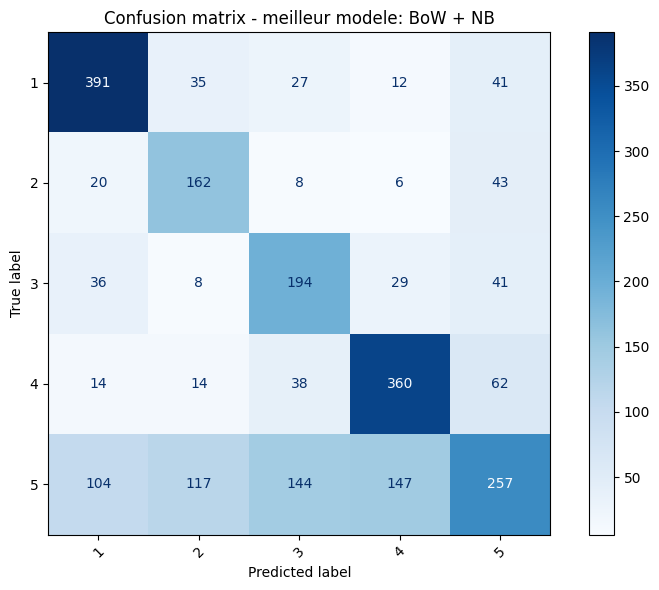


Meilleur modele retenu: BoW + NB


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 5) Entrainement + evaluation
results = []
best_name = None
best_pipe = None
best_f1 = -1

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)

    acc = accuracy_score(y_val, pred)
    f1_macro = f1_score(y_val, pred, average="macro")

    results.append({
        "Modele": name,
        "Accuracy": round(acc, 4),
        "F1_macro": round(f1_macro, 4),
    })

    print("\n" + "=" * 80)
    print("Modele:", name)
    print("=" * 80)
    print(classification_report(y_val, pred, digits=4, zero_division=0))

    if f1_macro > best_f1:
        best_f1 = f1_macro
        best_name = name
        best_pipe = pipe

df_results = pd.DataFrame(results).sort_values("F1_macro", ascending=False)
print("\nComparaison rapide:")
display(df_results)

best_pred = best_pipe.predict(X_val)
label_names = sorted(list(set(labels)))

cm = confusion_matrix(y_val, best_pred, labels=label_names)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d",
)
plt.title(f"Confusion matrix - meilleur modele: {best_name}")
plt.tight_layout()
plt.show()

print("\nMeilleur modele retenu:", best_name)

## Etape 6 - Conclusion rapide

Ecrire 4-5 lignes:
- quel modele est le meilleur,
- quelles classes sont bien / mal predites,
- quel impact du pretraitement.